INFO:purepyindi2.transports:Connected to localhost:7624


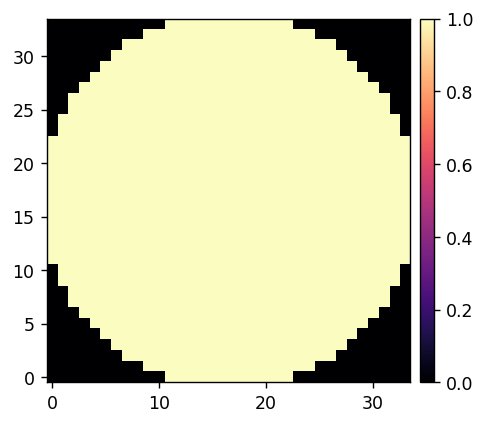

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [146]:
import numpy as np
import astropy.units as u
from astropy.io import fits
import time 
from importlib import reload
import copy
from datetime import datetime


import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle, Rectangle

import scoobscc


from scoobscc.math_module import xp, xcipy, ensure_np_array
from scoobscc import utils, telem, dm
from scoobscc import scc
import scoobscc.scoob_interface as scoobi

import scoobpy


from magpyx.utils import ImageStream

import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient
client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

wavelength_c = 633e-9
camsci_pxscl = 4.6e-6
camsci_pxscl_lamDc = 0.307 / 2 # divide by 2 for bin 1 

dm_mask = ensure_np_array(dm.make_mask(34))
utils.imshow([dm_mask])

%load_ext autoreload
%autoreload 2

## Experiment Directory

In [147]:
today = int(datetime.today().strftime('%Y%m%d'))
data_path = str(scoobscc.path)[:-9] + '/data_exp'

exp_path = data_path + f'/{today}_iscc_dig_mono'
telem.make_dir(exp_path)

Directory '/home/derbyk/src/scoob-scc/data_exp/20250626_iscc_dig_mono' already exists.


## Init Camera
### Phase Retrieval Cam

In [182]:
camlo_channel = 'camlo'

xc, yc = (3700, 3630)
ncamsci = 256

scoobi.set_cam_roi(xc, yc, ncamsci, client0, cam_name=camlo_channel, bin_mode=4)
time.sleep(1)
scoobi.set_cam_exp_time(1e-4, client0, cam_name=camlo_channel)
time.sleep(1)
scoobi.set_cam_gain(120, client0, cam_name=camlo_channel)
time.sleep(1)
scoobi.set_cam_blacklevel(4, client0, cam_name=camlo_channel)
time.sleep(1)

Set camlo ROI.
Set the camlo exposure time to 1.00e-04s
Set the camlo gain setting to 120.0
Set the camlo blacklevel to 4.0


In [194]:
scoobi.set_fib_atten(0, client)

Set the fiber attenuation to 0.0


### Science Cam

In [195]:
camsci_channel = 'camsci'
dm_ho_channel = 'dm00disp03'

xc, yc = (5680, 2615)
ncamsci = 512

scoobi.set_cam_roi(xc, yc, ncamsci, client0, cam_name=camsci_channel, bin_mode=1)
time.sleep(1)
scoobi.set_cam_exp_time(1e-3, client0, cam_name=camsci_channel)
time.sleep(1)
scoobi.set_cam_gain(120, client0, cam_name=camsci_channel)
time.sleep(1)
scoobi.set_cam_blacklevel(4, client0, cam_name=camsci_channel)
time.sleep(1)

camsci_stream = ImageStream(camsci_channel)
dm_ho_stream = ImageStream(dm_ho_channel)

Set camsci ROI.
Set the camsci exposure time to 1.00e-03s
Set the camsci gain setting to 120.0
Set the camsci blacklevel to 4.0


## Dark Frames
### Calibration

Move stagelinear to 40, 60 seems to introduce stray light.

In [8]:
scoobi.move_block_in(client0)

Set the camsci exposure time to 1.00e+00s
{'texp': 1.0, 'gain': 120.0, 'atten': 0.0}


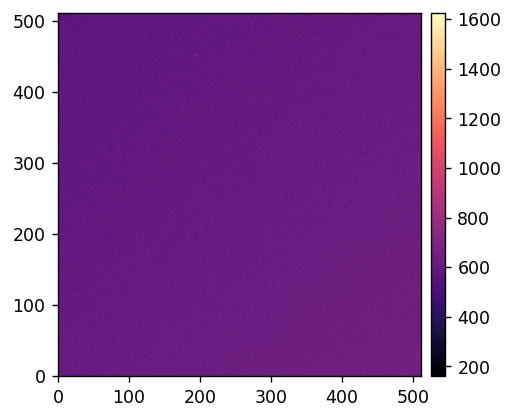

In [8]:
texp = 1

scoobi.set_cam_exp_time(texp, client0, cam_name=camsci_channel)
time.sleep(3)

dark_params = scoobi.get_im_params(client0, client, cam_name=camsci_channel)
dark_params.update({'atten':0.0})
dark_frame = scoobi.snap(camsci_stream, 100)

print(dark_params)
utils.imshow([dark_frame])

hdu = fits.PrimaryHDU(data=dark_frame)
hdr = hdu.header
hdr['TEXP'] = dark_params['texp']
hdr['GAIN'] = dark_params['gain']
hdr['ATTEN'] = dark_params['atten']

hdu.writeto(exp_path + f'/dark_frame_{texp:.0e}s.fits', overwrite=True)

In [11]:
scoobi.move_block_out(client0)

### Load for Use

In [196]:
dark_1s = utils.load_fits(exp_path + '/dark_frame_1e+00s.fits')
dark_100ms = utils.load_fits(exp_path + '/dark_frame_1e-01s.fits')
dark_10ms = utils.load_fits(exp_path + '/dark_frame_1e-02s.fits')
dark_1ms = utils.load_fits(exp_path + '/dark_frame_1e-03s.fits')
dark_100us = utils.load_fits(exp_path + '/dark_frame_1e-04s.fits')

## Move PSF

In [197]:
scoobi.set_cam_exp_time(1e-3, client0, cam_name=camsci_channel)

Set the camsci exposure time to 1.00e-03s


In [349]:
scoobpy.utils.move_relative(client=client, device='stagepiezo.stagepupil_x_pos', val=-1)

In [353]:
scoobpy.utils.move_relative(client=client, device='stagepiezo.stagepupil_y_pos', val=-1)

## Get Reference PSF

In [230]:
scoobi.set_fib_atten(35, client)

Set the fiber attenuation to 35.0


INFO:utils:Got semaphore index 1.


{'texp': 0.00100000004749745, 'gain': 120.0, 'atten': 35.0, 'Iref': 28325.68}


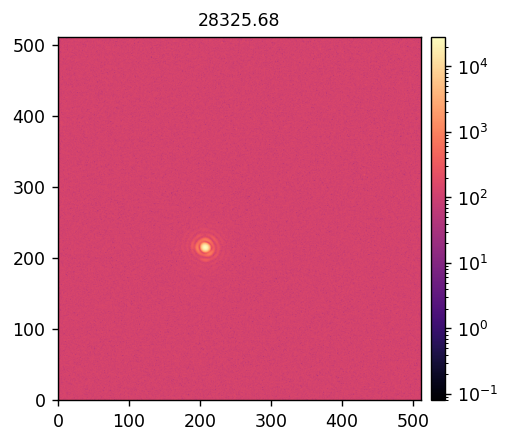

In [231]:
ref_psf = scoobi.snap(camsci_stream, 200)
Iref = np.max(ref_psf)

ref_params = scoobi.get_im_params(client0, client, cam_name=camsci_channel)
ref_params.update({'atten':35.0})
ref_params.update({'Iref': Iref})

print(ref_params)
utils.imshow([ref_psf], titles=[f'{Iref:.2f}'], norms=[LogNorm()])

In [232]:
hdu = fits.PrimaryHDU(data=ref_psf)
hdr = hdu.header
hdr['TEXP'] = ref_params['texp']
hdr['GAIN'] = ref_params['gain']
hdr['ATTEN'] = ref_params['atten']

hdu.writeto(exp_path + '/ref_psf.fits', overwrite=True)

scoobi.set_fib_atten(0, client)

Set the fiber attenuation to 0.0


## Set Control Region

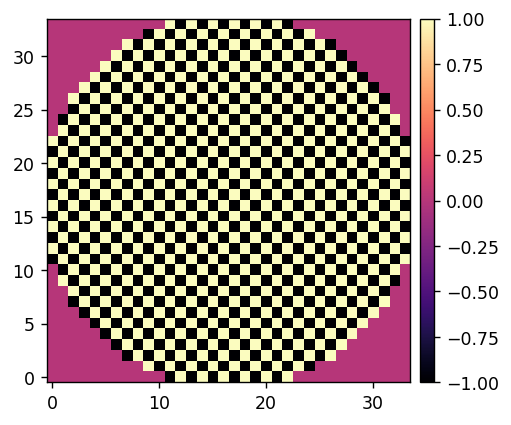

In [257]:
waffle_command = ensure_np_array(dm.make_fourier_command(x_cpa=17, y_cpa=17)) * dm_mask
utils.imshow([waffle_command])

{'texp': 0.00100000004749745, 'gain': 120.0, 'atten': 0.0}


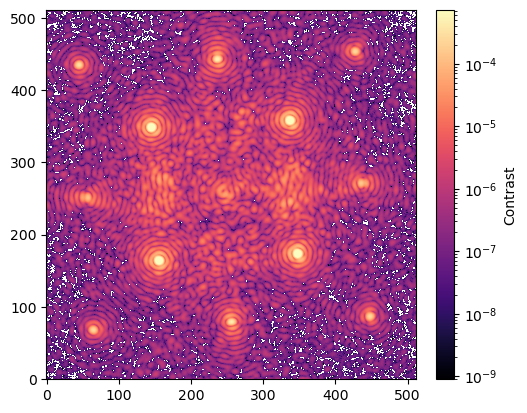

In [258]:
im_params = scoobi.get_im_params(client0, client, cam_name=camsci_channel)
im_params.update({'atten':0.0})

scoobi.set_dm(dm_ho_stream, 50e-9 * waffle_command)
waffle_im = scoobi.snap(camsci_stream, 100, ensure_np_array(dark_1ms), im_params, ref_params)

print(im_params)
plt.figure()
plt.imshow(waffle_im, norm='log', cmap='magma')
plt.colorbar(fraction=0.046, pad=0.04, label='Contrast')

Centroids:
 [[155.94491795 163.51844764]
 [145.42351813 347.8392666 ]
 [337.12477959 357.41400776]
 [347.81016279 172.99670697]
 [155.94491795 163.51844764]]


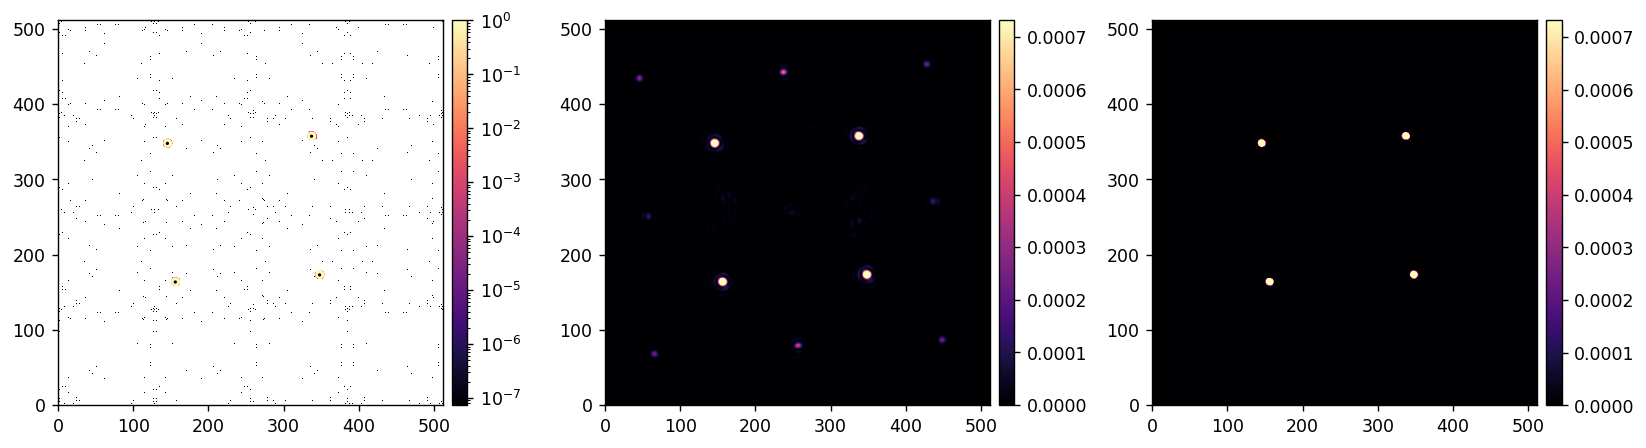

Angle:  86.93235676507064
Measured center in X:  246.5465297392415
Measured center in Y:  260.478728469619
Required shift in X:  9.0
Required shift in Y:  -4.0


In [259]:
scoobi.zero_dm(dm_ho_stream)

xshift, yshift, angle = utils.measure_waffle_center_and_angle(
    xp.array(waffle_im), 
    camsci_pxscl_lamDc, 
    im_thresh=5e-4, 
    r_thresh_min=16,
    r_thresh_max=25,
)

In [260]:
iwa = 3
owa = 10
rotation = angle - 90

control_mask = ensure_np_array( utils.create_annular_mask(
    ncamsci, 
    camsci_pxscl_lamDc,
    iwa, 
    owa, 
    edge=iwa, 
    x_shift=-xshift,
    y_shift=-yshift,
    rotation=rotation,
))

## Get Unmodulated Coro Image

stagepiezo at -1000 for unmodulated image

In [125]:
scoobpy.utils.move_relative(client=client, device='stagepiezo.stagefold_pos', val=-5000)

{'texp': 0.00100000004749745, 'gain': 120.0, 'atten': 0.0}


Text(0.5, 0.98, 'Control Region Contrast: 2.24e-06')

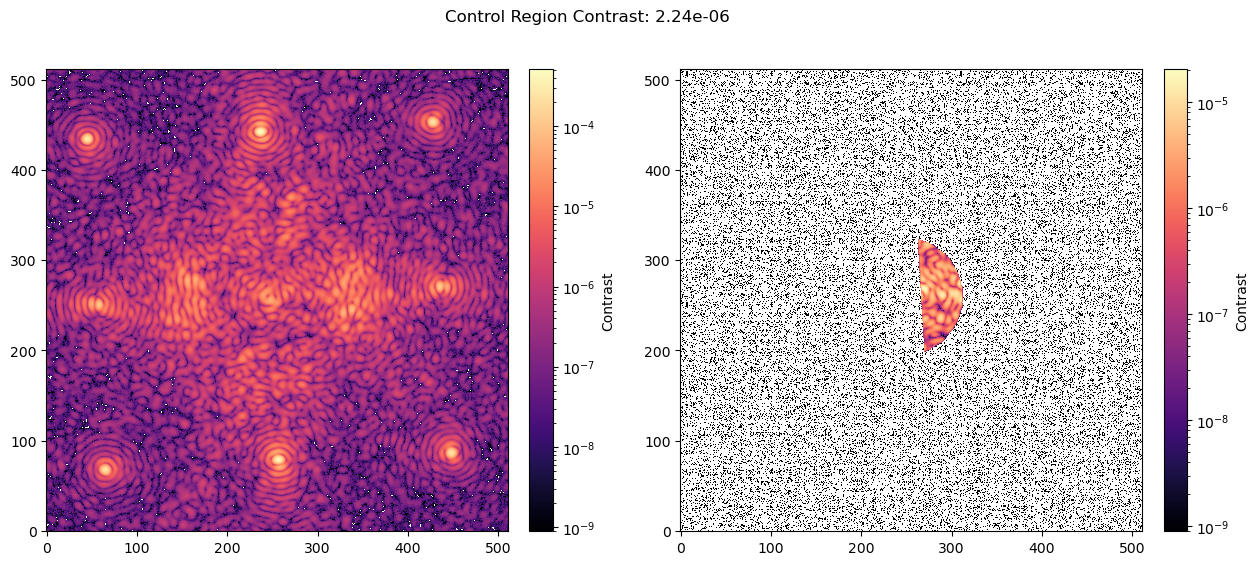

In [261]:
scoobi.zero_dm(dm_ho_stream)

im_params = scoobi.get_im_params(client0, client, cam_name=camsci_channel)
im_params.update({'atten':0.0})

im_unmod = scoobi.snap(camsci_stream, 200, ensure_np_array(dark_1ms), im_params, ref_params)
im_unmod[im_unmod < 0] = 0

print(im_params)
plt.figure(figsize=(15, 6))
plt.subplot(121)
plt.imshow(im_unmod, norm='log', cmap='magma')
plt.colorbar(fraction=0.046, pad=0.04, label='Contrast')
plt.subplot(122)
plt.imshow(im_unmod * control_mask, norm='log', cmap='magma')
plt.colorbar(fraction=0.046, pad=0.04, label='Contrast')
plt.suptitle(f'Control Region Contrast: {np.mean(im_unmod[control_mask]):.2e}')

## Get Modulated Coro Image

stagepizeo at 4000 for modulated image if starting from -1000, else move to -1000 first

In [264]:
scoobpy.utils.move_relative(client=client, device='stagepiezo.stagefold_pos', val=-5000)

{'texp': 0.00100000004749745, 'gain': 120.0, 'atten': 0.0}


Text(0.5, 0.98, 'Control Region Contrast: 2.34e-06')

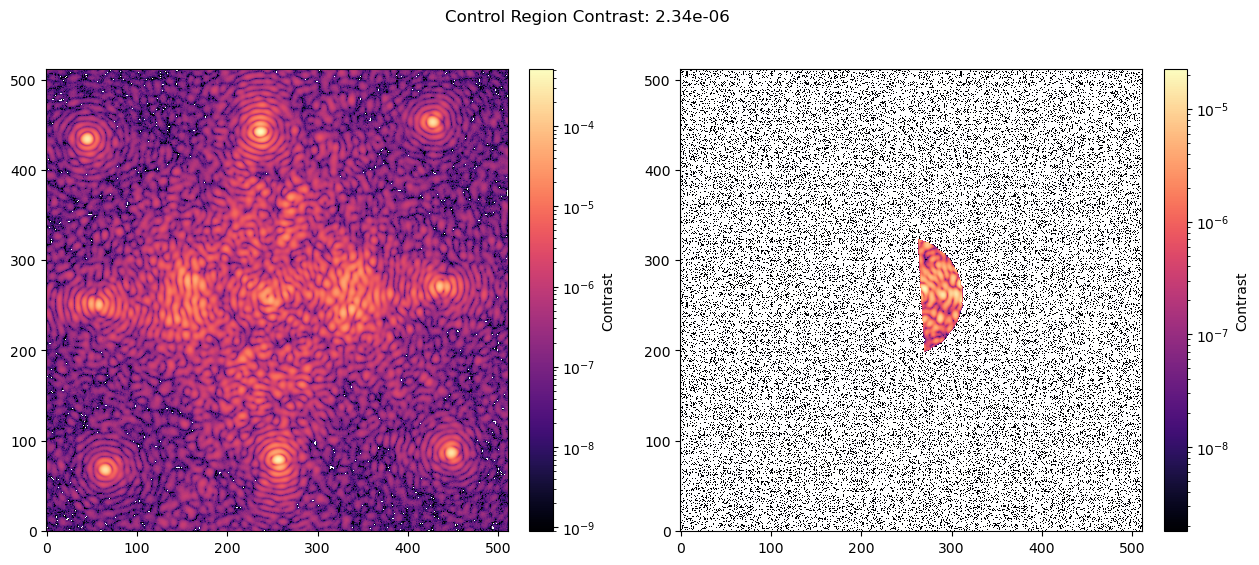

In [263]:
scoobi.zero_dm(dm_ho_stream)

im_params = scoobi.get_im_params(client0, client, cam_name=camsci_channel)
im_params.update({'atten':0.0})

im_mod = scoobi.snap(camsci_stream, 200, ensure_np_array(dark_1ms), im_params, ref_params)
im_mod[im_mod < 0] = 0

print(im_params)
plt.figure(figsize=(15, 6))
plt.subplot(121)
plt.imshow(im_mod, norm='log', cmap='magma')
plt.colorbar(fraction=0.046, pad=0.04, label='Contrast')
plt.subplot(122)
plt.imshow(im_mod * control_mask, norm='log', cmap='magma')
plt.colorbar(fraction=0.046, pad=0.04, label='Contrast')
plt.suptitle(f'Control Region Contrast: {np.mean(im_mod[control_mask]):.2e}')

## Get SCC Reference

stagepiezo at 69000 for SCC reference

In [268]:
scoobpy.utils.move_relative(client=client, device='stagepiezo.stagefold_pos', val=-70000)

In [269]:
scoobi.set_cam_exp_time(1e-3, client0, cam_name=camsci_channel)

Set the camsci exposure time to 1.00e-03s


{'texp': 0.100000001490116, 'gain': 120.0, 'atten': 0.0}


Text(0.5, 1.0, 'Control Region Contrast: 8.45e-08')

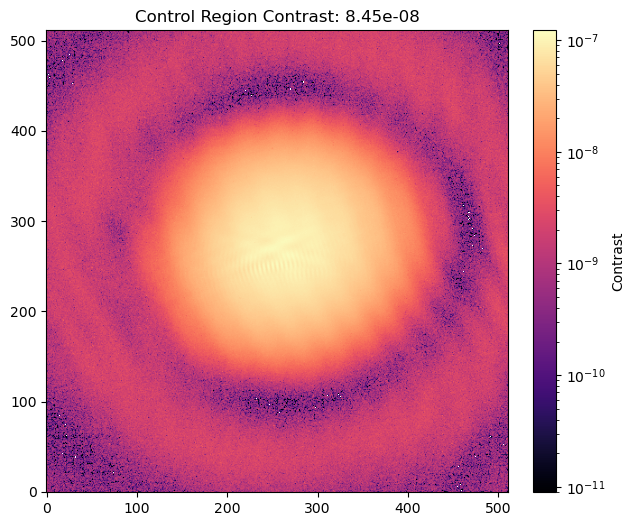

In [267]:
scoobi.zero_dm(dm_ho_stream)

im_params = scoobi.get_im_params(client0, client, cam_name=camsci_channel)
im_params.update({'atten':0.0})

ref_scc = scoobi.snap(camsci_stream, 200, ensure_np_array(dark_100ms), im_params, ref_params)
ref_scc[ref_scc < 0] = 0

print(im_params)
plt.figure(figsize=(8, 6))
plt.imshow(ref_scc, norm='log', cmap='magma')
plt.colorbar(fraction=0.046, pad=0.04, label='Contrast')
plt.title(f'Control Region Contrast: {np.mean(ref_scc[control_mask]):.2e}')

In [270]:
hdu = fits.PrimaryHDU(data=ref_scc)
hdr = hdu.header
hdr['TEXP'] = im_params['texp']
hdr['GAIN'] = im_params['gain']
hdr['ATTEN'] = im_params['atten']

hdu.writeto(exp_path + '/ref_scc.fits', overwrite=True)

In [339]:
ref_scc = fits.getdata('/home/derbyk/src/scoob-scc/data_exp/20250618_iscc_dig_mono/ref_scc.fits')

## Create DM Control Modes

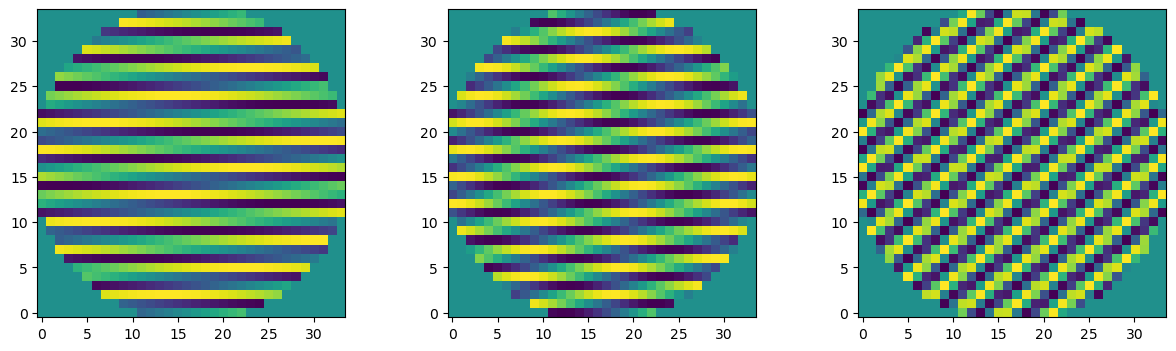

In [354]:
# dm_modes = ensure_np_array(dm.create_hadamard_modes(xp.array(dm_mask))) 
# scale_factors = scc.compute_hadamard_scale_factors(xp.array(dm_modes), scale_exp=1/5, scale_thresh=4, oversamp=3, plot=True)

dm_modes = ensure_np_array(dm.create_fourier_modes(dm_mask=xp.asarray(dm_mask), npsf=im_mod.shape[0], psf_pixelscale_lamD=camsci_pxscl_lamDc, 
                                                   iwa=iwa-2, owa=owa+2, fourier_sampling=0.75, which='both'))
scale_factors = None

plt.figure(figsize=(15, 4))
plt.subplot(131)
plt.imshow(dm_modes[1])
plt.subplot(132)
plt.imshow(dm_modes[10])
plt.subplot(133)
plt.imshow(dm_modes[100])

## Calibrate Jacobian

### Modulated Image Cube

stagepiezo at 4000 from -1000, else move to -1000 first then to 40000

In [341]:
scoobpy.utils.move_relative(client=client, device='stagepiezo.stagefold_pos', val=5000)

In [355]:
dark = dark_1ms
scoobi.set_cam_exp_time(1e-3, client0, cam_name=camsci_channel)
time.sleep(3)
im_params = scoobi.get_im_params(client0, client, cam_name=camsci_channel)
im_params.update({'atten':0.0})

print(im_params)

Set the camsci exposure time to 1.00e-03s
{'texp': 0.00100000004749745, 'gain': 120.0, 'atten': 0.0}


In [356]:
scoobi.zero_dm(dm_ho_stream)
current_command = dm_ho_stream.grab_latest() * 1e-6

In [360]:
dm_ho_stream.write((current_command + ensure_np_array(4e-9 * dm_modes[100])) * 1e6)

In [361]:
calibration_amplitude = 4e-9
delay = 0.01
NFRAMES = 10

### init stuff
scoobi.zero_dm(dm_ho_stream)
current_command = dm_ho_stream.grab_latest() * 1e-6

Nact = dm_modes.shape[1]
Nmask = int(control_mask.sum())
Nmodes = dm_modes.shape[0]
Ncamsci = camsci_stream.shape[0]

ims_mod = np.zeros((Ncamsci, Ncamsci, Nmodes, 2))
ims_unmod = np.zeros((Ncamsci, Ncamsci, Nmodes, 2))

calib_amps = np.array([-calibration_amplitude, calibration_amplitude])

# get modulated images
start = time.time()
for i, mode in enumerate(dm_modes):

    for j, calib_amp in enumerate(calib_amps):

        dm_mode = mode.reshape(Nact, Nact)
        amp = calib_amp * scale_factors[i] if scale_factors is not None else calib_amp
        dm_command = ensure_np_array(amp * dm_mode)

        dm_ho_stream.write((current_command + dm_command) * 1e6)
        time.sleep(delay)

        im = scoobi.snap(camsci_stream, NFRAMES, utils.ensure_np_array(dark), im_params, ref_params)
        im[im < 0] = 0
        ims_mod[:, :, i, j] = im

    print(f"\tSnapped modulated images of mode {i + 1:d}/{dm_modes.shape[0]:d} in {time.time()-start:.3f}s", end='')
    print("\r", end="")

### Unmodulated Image Cube

stagepiezo at -1000

In [362]:
scoobpy.utils.move_relative(client=client, device='stagepiezo.stagefold_pos', val=-5000)
scoobi.zero_dm(dm_ho_stream)

In [363]:
# get unmodulated images
start = time.time()
for i, mode in enumerate(dm_modes):

    for j, calib_amp in enumerate(calib_amps):

        dm_mode = mode.reshape(Nact, Nact)
        amp = calib_amp * scale_factors[i] if scale_factors is not None else calib_amp
        dm_command = ensure_np_array(amp * dm_mode)

        dm_ho_stream.write((current_command + dm_command) * 1e6)
        time.sleep(delay)

        im = scoobi.snap(camsci_stream, NFRAMES, utils.ensure_np_array(dark), im_params, ref_params)
        im[im < 0] = 0
        ims_unmod[:, :, i, j] = im

    print(f"\tSnapped unmodulated images of mode {i + 1:d}/{dm_modes.shape[0]:d} in {time.time()-start:.3f}s", end='')
    print("\r", end="")

### Filter

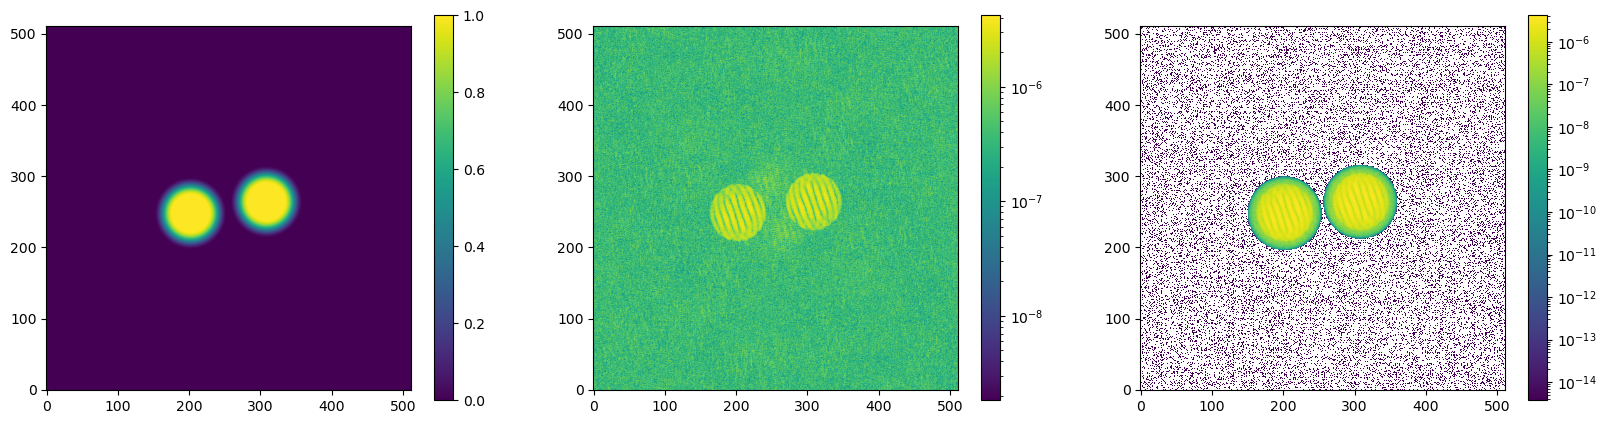

In [364]:
ind = 400
diff1 = ims_mod[:, :, ind, 0] - ims_mod[:, :, ind, 1]
diff2 = ims_unmod[:, :, ind, 0] - ims_unmod[:, :, ind, 1]
ddiff = diff1 - diff2
fft_ddiff = xp.fft.fftshift(xp.fft.ifft2(xp.fft.ifftshift(ddiff), norm='ortho'))

x, y = xp.meshgrid(xp.linspace(-0.5, 0.5, ims_mod[:, :, 0, 0].shape[0]), xp.linspace(-0.5, 0.5, ims_mod[:, :, 0, 0].shape[0]))

alpha = 0.5
N = 0.2
x_offset = 0.104
y_offset = 0.016

tukey = xp.zeros_like(x)

r1 = xp.sqrt((x - x_offset) ** 2 + (y - y_offset) ** 2)
r2 = xp.sqrt((x + x_offset) ** 2 + (y + y_offset) ** 2)

b1 = alpha * N / 2 # N / 2 * (1 + alpha)
b2 = N / 2

mask = (r1 < b1) | (r2 < b1)
tukey[mask] = 1

mask = (r1 >= b1) & (r1 <= b2)
tukey[mask] = 0.5 * (1 - xp.cos((2 * xp.pi * r1[mask]) / (alpha * N)))

mask = (r2 >= b1) & (r2 <= b2)
tukey[mask] = 0.5 * (1 - xp.cos((2 * xp.pi * r2[mask]) / (alpha * N)))

plt.figure(figsize=(20, 5))
plt.subplot(131)
plt.imshow(tukey.get())
plt.colorbar()
plt.subplot(132)
plt.imshow(xp.abs(fft_ddiff).get(), norm='log')
plt.colorbar()
plt.subplot(133)
plt.imshow(xp.abs(fft_ddiff).get() * tukey.get(), norm='log')
plt.colorbar()

### Calculation

In [365]:
Nmask = int(control_mask.sum())
Nmodes = dm_modes.shape[0]
Ncamsci = ims_mod[:, :, 0, 0].shape[0]

jacobian = xp.zeros((Nmask, Nmodes))
jacobian_full = xp.zeros((Ncamsci ** 2, Nmodes))

for i in range(Nmodes):

    amp = calib_amp * scale_factors[i] if scale_factors is not None else calib_amp

    diff1 = ims_mod[:, :, i, 0] - ims_mod[:, :, i, 1]
    diff2 = ims_unmod[:, :, i, 0] - ims_unmod[:, :, i, 1]
    ddiff = diff1 - diff2

    fft_ddiff = xp.fft.fftshift(xp.fft.ifft2(xp.fft.ifftshift(ddiff), norm='ortho'))
    ddiff_hp = xp.fft.ifftshift(xp.fft.fft2(xp.fft.fftshift(fft_ddiff * tukey), norm='ortho')).real

    response = ddiff_hp / (2 * amp)

    jacobian[:, i] = response[control_mask].ravel()
    jacobian_full[:, i] = response.ravel()

In [366]:
hdu = fits.PrimaryHDU(data=ensure_np_array(ims_mod))
hdr = hdu.header
hdr['TEXP'] = 1e-3
hdr['GAIN'] = 120.0
hdr['ATTEN'] = 0.0

hdu.writeto(exp_path + '/jac_ims_mod.fits', overwrite=True)

hdu = fits.PrimaryHDU(data=ensure_np_array(ims_unmod))
hdr = hdu.header
hdr['TEXP'] = 1e-3
hdr['GAIN'] = 120.0
hdr['ATTEN'] = 0.0

hdu.writeto(exp_path + '/jac_ims_unmod.fits', overwrite=True)

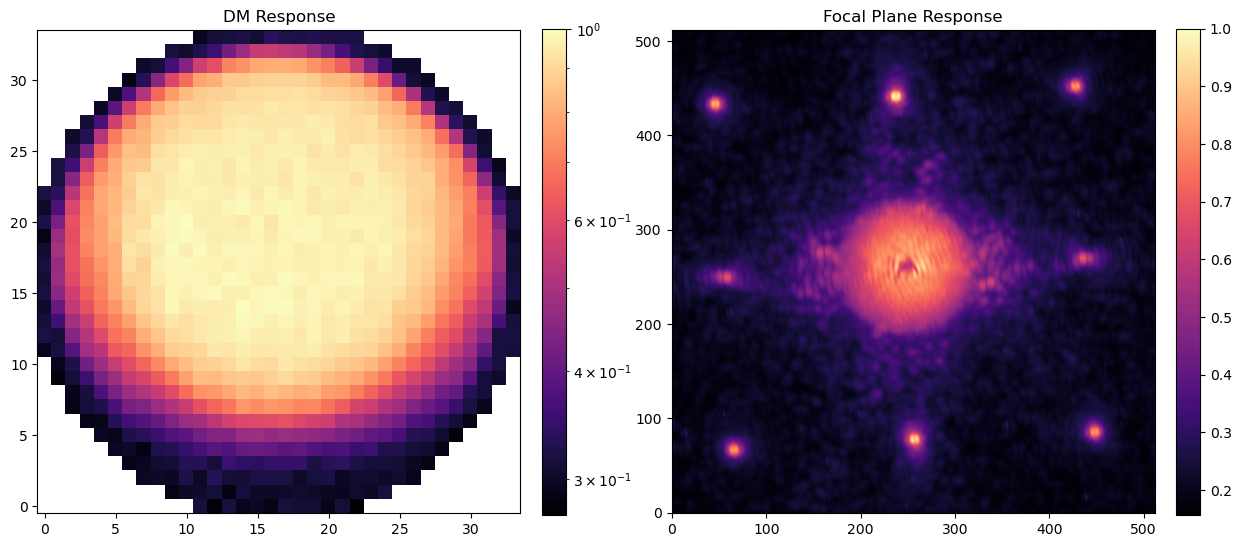

In [367]:
dm_modes = utils.ensure_np_array(dm_modes)

dm_response_map = np.sqrt(np.mean(np.abs(utils.ensure_np_array(jacobian).dot(dm_modes.reshape(dm_modes.shape[0], -2))), axis=0))
dm_response_map = dm_response_map.reshape(34, 34) / np.max(dm_response_map)

fp_response_map = np.sqrt(np.mean(np.abs(utils.ensure_np_array(jacobian_full)), axis=1)).reshape(512, 512)
fp_response_map /= np.max(fp_response_map)

plt.figure(figsize=(15, 7))
plt.subplot(121)
plt.title('DM Response')
plt.imshow(dm_response_map, cmap='magma', norm='log')
plt.colorbar(fraction=0.046, pad=0.04)
plt.subplot(122)
plt.title('Focal Plane Response')
plt.imshow(fp_response_map, cmap='magma')
plt.colorbar(fraction=0.046, pad=0.04)

In [368]:
cmTI = utils.TikhonovInverse(jacobian, rcond=1e-2)
cm20 = utils.beta_reg(jacobian, -2)
cm25 = utils.beta_reg(jacobian, -2.5)
cm30 = utils.beta_reg(jacobian, -3)
cm35 = utils.beta_reg(jacobian, -3.5)
cm40 = utils.beta_reg(jacobian, -4)
cm45 = utils.beta_reg(jacobian, -4.5)
cm50 = utils.beta_reg(jacobian, -5)

In [403]:
scoobi.zero_dm(dm_ho_stream)

data = {
    'images_mod'   : [],
    'images_unmod' : [],
    'commands'     : [],
    'image_params' : [],
    'beta'         : [],
    'nframes'      : [],
    'gain'         : [],
    'leakage'      : [],
    'filter'       : 0,
    'pixelscale'   : camsci_pxscl_lamDc,
    'control_mask' : control_mask, 
}

In [410]:
dark = dark_1ms
scoobi.set_cam_exp_time(1e-1, client0, cam_name=camsci_channel)
time.sleep(3)
im_params = scoobi.get_im_params(client0, client, cam_name=camsci_channel)
im_params.update({'atten':0.0})
cm = cm40
beta = 2
iterations=2

print(im_params)

Set the camsci exposure time to 1.00e-01s
{'texp': 0.100000001490116, 'gain': 120.0, 'atten': 0.0}


Running SCC...
	Iteration 1 / 2
Pinhole is blocked, moving stagepiezo...
Taking modulated image...
Finished taking modulated image, moving stagepiezo...
Taking unmodulated image...


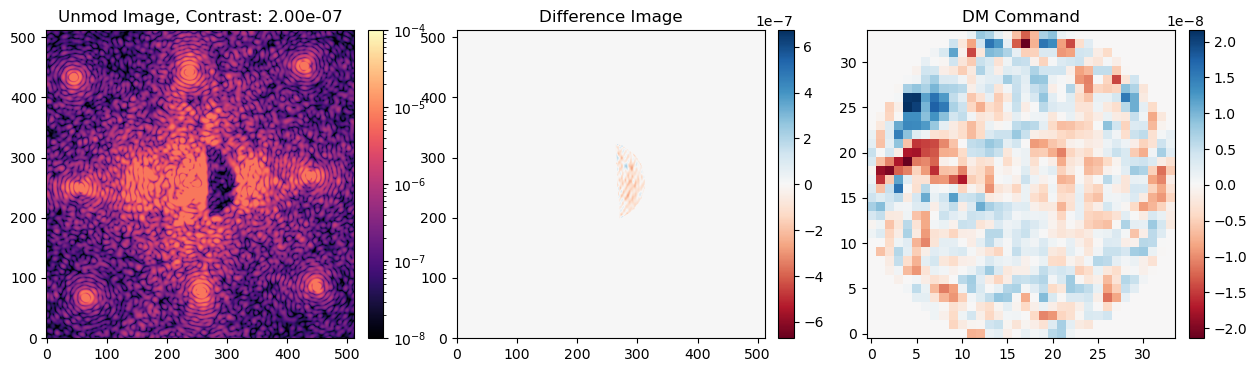

	Iteration 2 / 2
Pinhole is blocked, moving stagepiezo...


KeyboardInterrupt: 

In [411]:
data = scc.run_int(data=data,
                    INDIclient=client,
                    camsci_stream=camsci_stream, 
                    dm_stream=dm_ho_stream, 
                    control_matrix=cm,
                    calibration_modes=dm_modes,
                    control_mask=control_mask,
                    scc_reference=ref_scc,
                    im_params=im_params,
                    ref_psf_params=ref_params, 
                    dark_frame=utils.ensure_np_array(dark), 
                    filter=None,
                    beta=beta,
                    NFRAMES=200, 
                    delay=1,
                    num_iterations=iterations,
                    gain=0.75, 
                    leakage=0.0,
                    plot=True)

Text(0, 0.5, 'Mean Contrast')

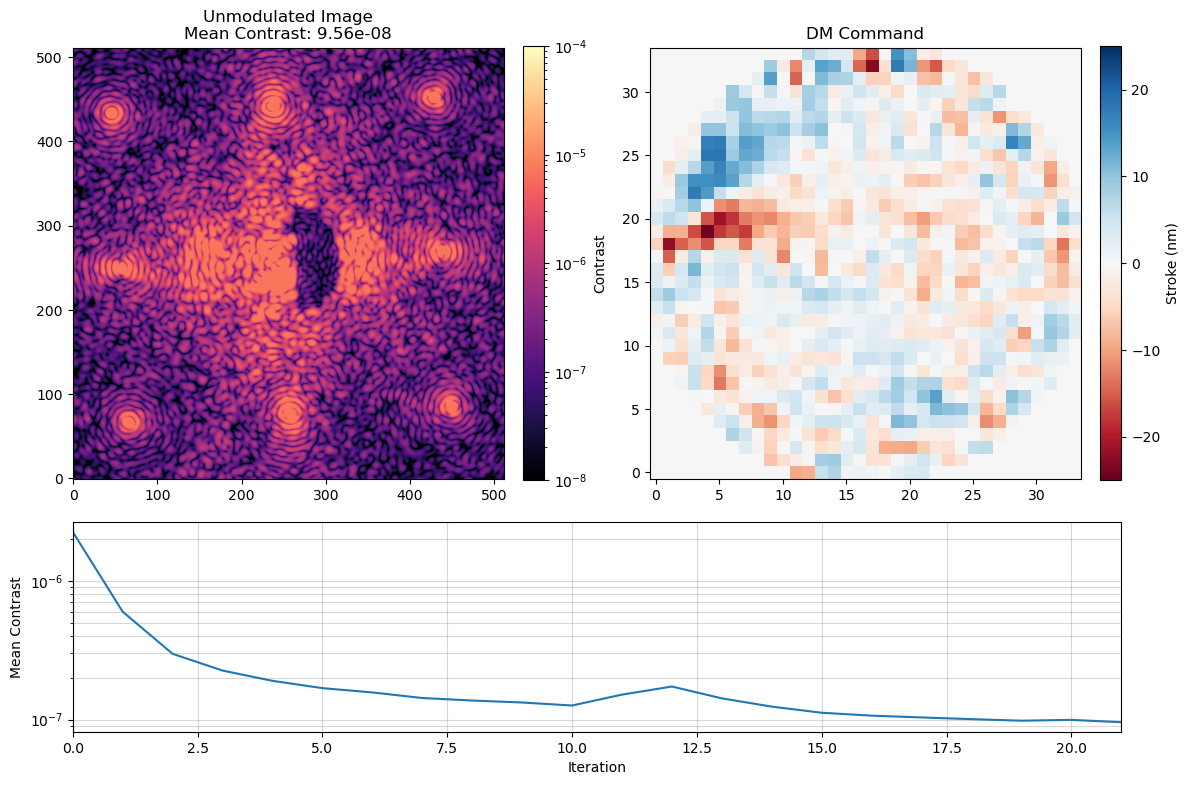

In [402]:
image = data['images_unmod'][-1]
command = data['commands'][-1]
mask = data['control_mask']
contrasts = [np.mean(im[mask]) for im in data['images_unmod']]

fig = plt.figure(figsize=(12, 8), layout='tight')
gs = plt.GridSpec(nrows=3, ncols=4)

ax1 = fig.add_subplot(gs[0:2, 0:2])
m = ax1.imshow(image, norm='log', cmap='magma', vmin=1e-8, vmax=1e-4)
plt.colorbar(m, fraction=0.046, pad=0.04, label='Contrast')
ax1.set_title(f'Unmodulated Image\nMean Contrast: {np.mean(image[mask]):.2e}')

ax2 = fig.add_subplot(gs[0:2, 2:])
m = ax2.imshow(command * 1e9, cmap='RdBu', vmin=-25, vmax=25)
plt.colorbar(m, fraction=0.046, pad=0.04, label='Stroke (nm)')
ax2.set_title('DM Command')

ax3 = fig.add_subplot(gs[2, :])
ax3.semilogy(contrasts)
ax3.grid(which='both', axis='both', alpha=0.5)
ax3.set_xlim([0, len(contrasts) - 1])
ax3.set_xlabel('Iteration')
ax3.set_ylabel('Mean Contrast')

In [401]:
utils.save_pickle(exp_path + '/dig01.pkl', data)

Saved data to:  /home/derbyk/src/scoob-scc/data_exp/20250626_iscc_dig_mono/dig01.pkl
